In [1]:
import numpy as np
import pandas as pd
import gc
from tqdm.notebook import tqdm
from multiprocessing import Pool
import os
os.chdir('/home/bhanselman/gbt_mias/ronit')
from spectra import *

In [2]:
data_dir = "/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/rebinned_spectra/"
spectra = os.listdir(data_dir)

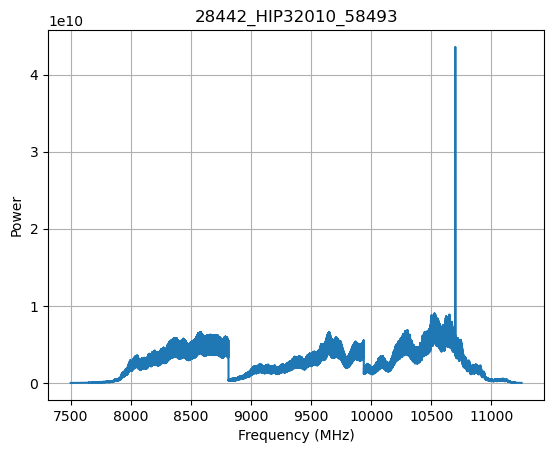

In [3]:
spectrum = Spectrum(data_dir + spectra[0])
spectrum.plot()

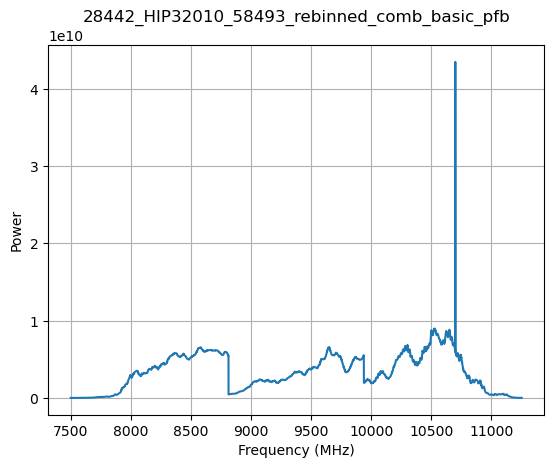

In [4]:
spectrum.basic_pfb('rebinned_comb.npy')
spectrum.plot()

In [5]:
spectrum.num_unit_cells()

1280

In [6]:
spectrum.freq, spectrum.power

(array([ 7501.55639648,  7501.73950195,  7501.92260742, ...,
        11251.00708008, 11251.19018555, 11251.37329102]),
 array([8909908.06249097, 8331049.20545187, 8203010.11326808, ...,
        7366187.3401235 , 7422980.96641388, 7709407.58579513]))

In [7]:
spectrum.cell_size

16

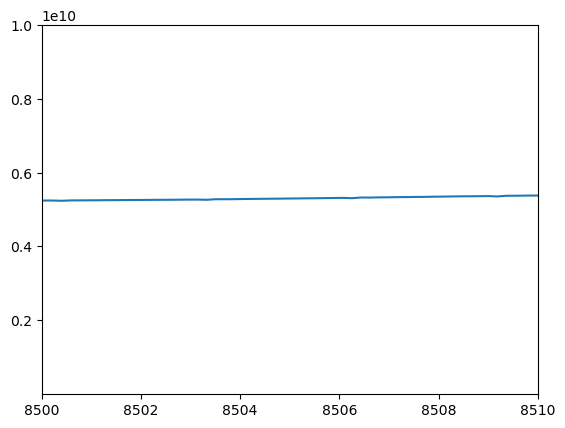

In [8]:
import matplotlib.pyplot as plt
plt.plot(spectrum.freq, spectrum.power)
plt.xlim(8500,8510)
plt.ylim(1,1e10)
plt.savefig('combed.png')

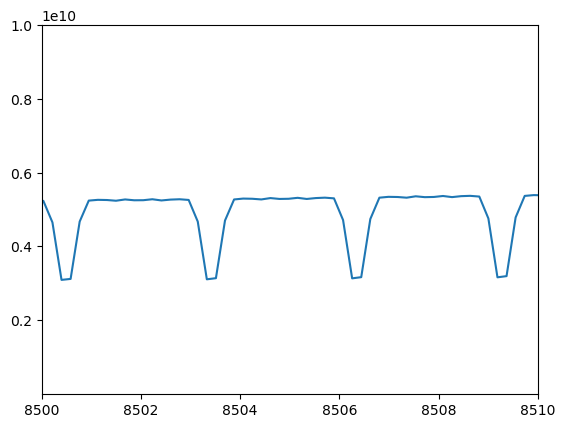

In [9]:
original = Spectrum(data_dir + spectra[0])
plt.plot(original.freq, original.power)
plt.xlim(8500,8510)
plt.ylim(1,1e10)
plt.savefig('uncombed.png')

# Grouping objects together

In [10]:
groups = {}
for loc in spectra:
    source = loc.split('_')[-2]
    if source not in groups:
        groups[source] = []
    groups[source].append(loc)
len(groups)

1924

In [11]:
df = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/xband_info.csv')
df = df[df['source'] == 'HIP32010']
df

,source,mjd,filename,l,b,theta,phi,nfw,nfw_sq,iso,iso_sq,burkert,burkert_sq,moore,moore_sq
1,HIP32010,58493.28442,spliced_blc00010203040506o7o0111213141516o7o02...,190.344555,8.571999,100.227749,166.595237,1.002481e+08,5.013778e+14,2.526118e+08,1.146479e+15,8.582130e+07,4.093387e+14,2.187004e+07,2.896061e+13
43,HIP32010,58493.29908,spliced_blc00010203040506o7o0111213141516o7o02...,190.340897,8.572337,100.224124,166.597825,1.002477e+08,5.013747e+14,2.526113e+08,1.146474e+15,8.582095e+07,4.093362e+14,2.186994e+07,2.896042e+13
49,HIP32010,58493.29123,spliced_blc00010203040506o7o0111213141516o7o02...,190.339927,8.573108,100.223145,166.598080,1.002476e+08,5.013744e+14,2.526112e+08,1.146474e+15,8.582091e+07,4.093359e+14,2.186994e+07,2.896040e+13
1979,HIP32010,58417.40392,spliced_blc00010203040506o7o0111213141516o7o02...,190.341968,8.572228,100.225186,166.597074,1.002478e+08,5.013756e+14,2.526114e+08,1.146476e+15,8.582105e+07,4.093369e+14,2.186997e+07,2.896047e+13
1983,HIP32010,58417.41090,spliced_blc00010203040506o7o0111213141516o7o02...,190.340695,8.572841,100.223911,166.597661,1.002477e+08,5.013749e+14,2.526113e+08,1.146474e+15,8.582097e+07,4.093363e+14,2.186995e+07,2.896043e+13
1987,HIP32010,58417.41775,spliced_blc00010203040506o7o0111213141516o7o02...,190.340544,8.572304,100.223776,166.598117,1.002476e+08,5.013743e+14,2.526112e+08,1.146474e+15,8.582091e+07,4.093359e+14,2.186993e+07,2.896040e+13


In [12]:
spectra = np.array([np.load(data_dir + loc) for loc in groups['HIP32010']])
xs = spectra[0,0]
ys = np.mean(spectra[:,1], axis=0)
np.array([xs,ys])

array([[7.50155640e+03, 7.50173950e+03, 7.50192261e+03, ...,
        1.12510071e+04, 1.12511902e+04, 1.12513733e+04],
       [5.29141250e+06, 7.40515358e+06, 8.17265175e+06, ...,
        7.34977733e+06, 6.58320558e+06, 4.55673567e+06]])

In [13]:
from astropy.coordinates import SkyCoord
def get_theta_phi(l, b):
    gal = SkyCoord(l, b, unit='deg', frame='galactic')
    v_sun = SkyCoord(90, 0, unit='deg', frame='galactic')
    v_gc = SkyCoord(0, 0, unit='deg', frame='galactic')
    theta = v_sun.separation(gal).deg
    phi = v_gc.separation(gal).deg
    return theta, phi

In [14]:
grouped_dir = "/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/rebinned_spectra_g/"

info = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/xband_info.csv')

In [14]:
#for source, locs in tqdm(groups.items()):
def group(item):
    source, locs = item
    spectra = np.array([np.load(data_dir + loc) for loc in locs])
    xs = spectra[0,0]
    ys = np.mean(spectra[:,1], axis=0)
    np.save(grouped_dir + source, np.array([xs,ys]))
    del spectra
    gc.collect()
    # Update csv
    filt = info[info['source'] == source]
    ls, bs = filt['l'].to_numpy(), filt['b'].to_numpy()
    l, b = np.mean(ls), np.mean(bs)
    theta, phi = get_theta_phi(l, b)
    return source, l, b, theta, phi
    
with Pool(maxtasksperchild=10) as p:
    data = list(tqdm(p.imap_unordered(group, groups.items()), total=len(groups)))
    
columns = ['source', 'l', 'b', 'theta', 'phi']
df = pd.DataFrame(data, columns=columns)
df.to_csv('/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/xband_info_g.csv', index=False)

100%|███████████████████████████████████████| 1924/1924 [01:01<00:00, 31.54it/s]


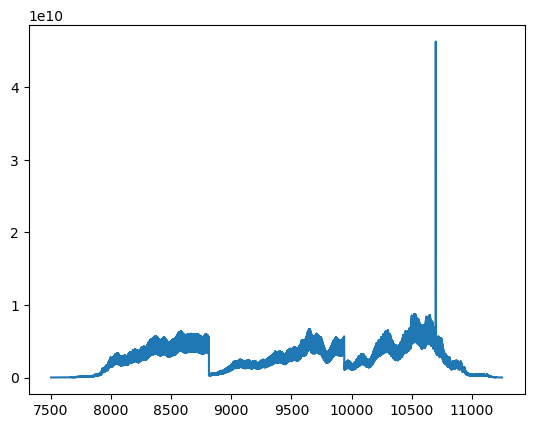

In [15]:
# Testy
spectra_g = os.listdir(grouped_dir)
one = np.load(grouped_dir + spectra_g[0])
plt.plot(one[0], one[1])

# Combing

In [15]:
combed_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/combed_g/'
ddir = grouped_dir
interpret = False
spectra_to_comb = os.listdir(ddir)

In [41]:
# The loop
def comb(loc):
    spectrum = Spectrum(ddir + loc, interpret=interpret)
    spectrum.basic_pfb('rebinned_comb.npy')
    combed = np.array([spectrum.freq, spectrum.power])
    np.save(combed_dir + loc, combed)
    del spectrum
    gc.collect()

with Pool(maxtasksperchild=10) as p:
    result = list(tqdm(p.imap_unordered(comb, spectra_to_comb), total=len(spectra_to_comb)))

100%|███████████████████████████████████████| 1924/1924 [01:18<00:00, 24.49it/s]


In [42]:
len(os.listdir(combed_dir))

1924

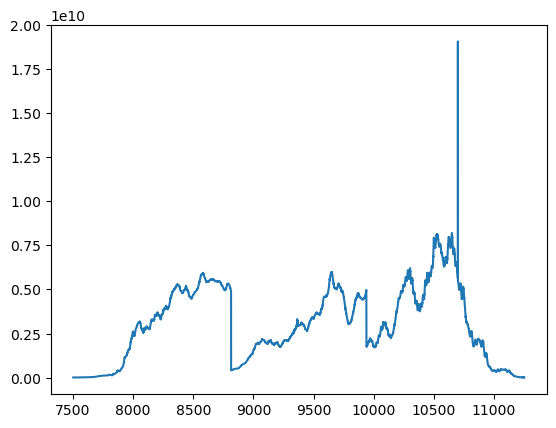

In [16]:
# Testy number 2
spectra_g = os.listdir(combed_dir)
one = np.load(combed_dir + spectra_g[0])
plt.plot(one[0], one[1])

# Removing discontinuities!

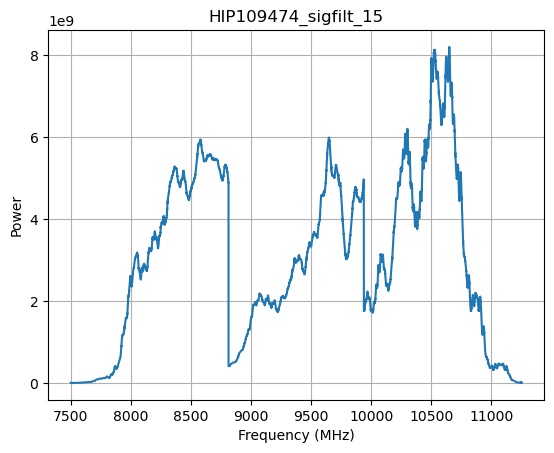

In [27]:
# Ronit's sigma_filter function
one = Spectrum(combed_dir + spectra_g[0], interpret=False)
one.sigma_filter()
one.plot()

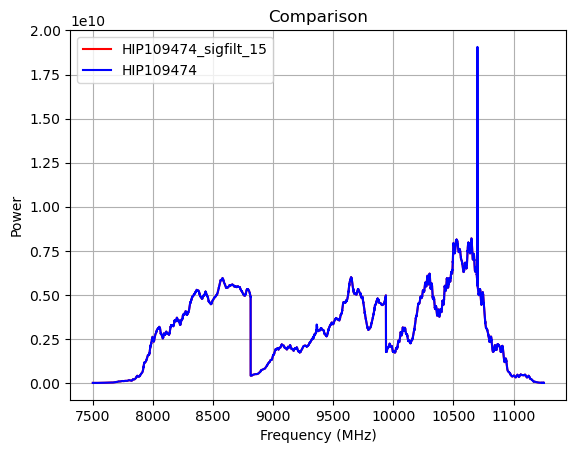

In [28]:
two = Spectrum(combed_dir + spectra_g[0], interpret=False)
plot_two_spectra(one, two)

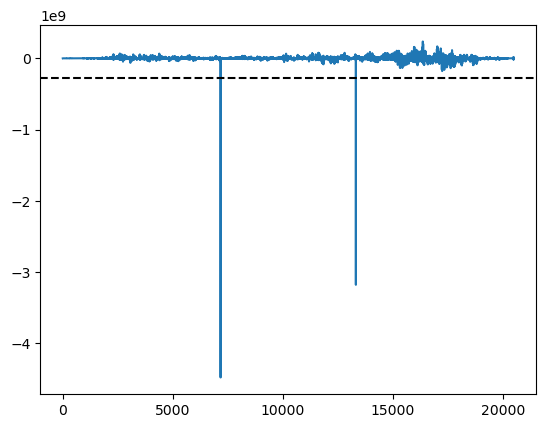

In [29]:
# Great, now for my cliff removal code...
grad = np.diff(one.power)
plt.plot(grad)
med, std = np.median(grad), np.std(grad)
plt.axhline(med - 7 * std, color='k', ls='--')

In [30]:
disc_inds = np.where(abs(grad - med) > 7 * std)[0]
disc_freqs = one.freq[disc_inds]
disc_powers = one.power[disc_inds]
disc_freqs, disc_powers

(array([8813.87329102, 9938.87329102]),
 array([4.89873625e+09, 4.96206738e+09]))

7697919.627781868 -881373.8699680567 3408272.8789069057
-10511513.617793083 -3574052.9006524086 -7042783.259222746


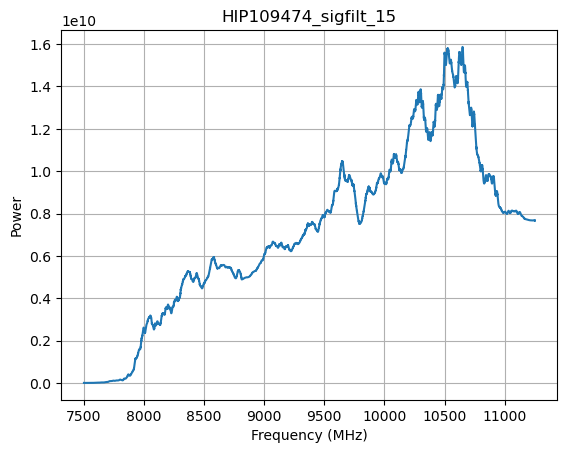

In [31]:
# Le algorithm
for i in disc_inds:
    diff = (grad[i-1] + grad[i+1]) / 2
    print(grad[i-1], grad[i+1], diff)
    one.power[i+1:] += one.power[i] - one.power[i+1] + diff
one.plot()

In [18]:
ddir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/combed_g/'
outdir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/cleaned_g/'

spectra_to_clean = os.listdir(ddir)

def clean(loc, nsigma=7):
    spectrum = Spectrum(ddir + loc, interpret=interpret)
    spectrum.sigma_filter()
    grad = np.diff(spectrum.power)
    med, std = np.median(grad), np.std(grad)
    disc_inds = np.where(abs(grad - med) > nsigma * std)[0]
    for i in disc_inds:
        diff = (grad[i-1] + grad[i+1]) / 2
        spectrum.power[i+1:] += diff - grad[i]
    cleaned = np.array([spectrum.freq, spectrum.power])
    np.save(outdir + loc, cleaned)
    del spectrum, grad, med, std, disc_inds, diff, cleaned
    gc.collect()

with Pool(maxtasksperchild=10) as p:
    result = list(tqdm(p.imap_unordered(clean, spectra_to_clean), total=len(spectra_to_clean)))

100%|███████████████████████████████████████| 1924/1924 [21:15<00:00,  1.51it/s]


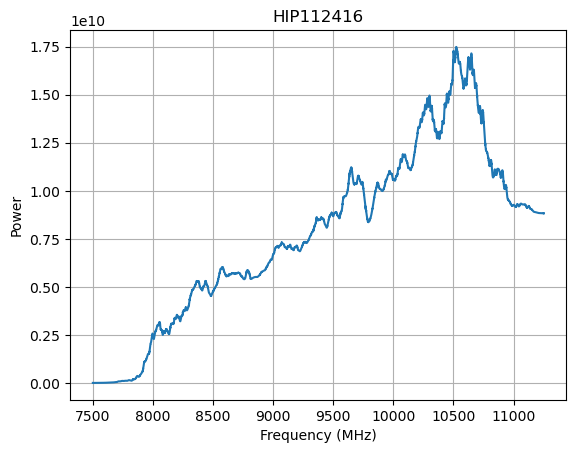

In [23]:
# Testy number 3
import random
loc = random.choice(os.listdir(outdir))
spectrum = Spectrum(outdir + loc, interpret=False)
spectrum.plot()